### Random Forest Classifier to Predict a Successful Vaginal Birth After C-Section

Now that we've created the most basic prediction model, we'll test a random forest classifier to see if it achieves better accuracy.

In [2]:
from pickle import load

x_train_unfiltered = load(
    open("../../../data/processed/vbac/X_train_prepared.pkl", "rb")
)
x_test_unfiltered = load(open("../../../data/processed/vbac/X_test_prepared.pkl", "rb"))
y_test = load(open("../../../data/processed/vbac/y_test.pkl", "rb"))
y_train = load(open("../../../data/processed/vbac/y_train.pkl", "rb"))
feature_importances_df = load(
    open("../../../data/processed/vbac/feature_importances_df.pkl", "rb")
)

We'll use our `feature_importances` dataframe to train a few versions of the model with different configurations of the data.

First, we'll try training using any feature with an importance > 0.01.

In [3]:
feature_importances_df.loc[feature_importances_df["importance"] > 0.01].index.tolist()

[1505,
 1504,
 1516,
 1585,
 1588,
 1600,
 1514,
 1598,
 1602,
 1550,
 1599,
 1591,
 1592,
 1597,
 1586,
 1587,
 1601]

In [4]:
x_train_001 = x_train_unfiltered[
    :,
    feature_importances_df.loc[
        feature_importances_df["importance"] > 0.01
    ].index.tolist(),
]
x_test_001 = x_test_unfiltered[
    :,
    feature_importances_df.loc[
        feature_importances_df["importance"] > 0.01
    ].index.tolist(),
]

In [5]:
from sklearn.ensemble import RandomForestClassifier

rfc_model_001 = RandomForestClassifier(random_state=14, class_weight="balanced")

rfc_model_001.fit(x_train_001, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [6]:
predictions_001 = rfc_model_001.predict(x_test_001)

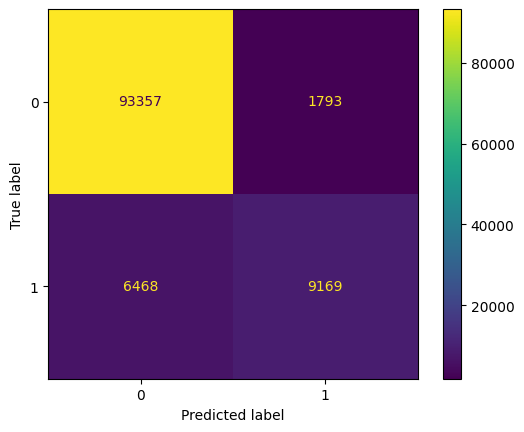

In [7]:
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, predictions_001)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=rfc_model_001.classes_
)
disp.plot()
plt.show()

In [8]:
from sklearn.metrics import f1_score

f1_001 = f1_score(y_test, predictions_001)

f1_001

0.6894244144516711

Next we'll train a model with features of importance > 0.15.

In [9]:
x_train_0015 = x_train_unfiltered[
    :,
    feature_importances_df.loc[
        feature_importances_df["importance"] > 0.015
    ].index.tolist(),
]
x_test_0015 = x_test_unfiltered[
    :,
    feature_importances_df.loc[
        feature_importances_df["importance"] > 0.015
    ].index.tolist(),
]

In [10]:
from sklearn.ensemble import RandomForestClassifier

rfc_model_0015 = RandomForestClassifier(random_state=14, class_weight="balanced")

rfc_model_0015.fit(x_train_0015, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [11]:
predictions_0015 = rfc_model_0015.predict(x_test_0015)

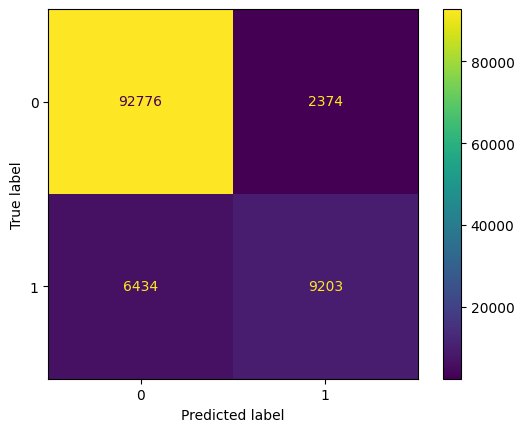

In [12]:
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, predictions_0015)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=rfc_model_0015.classes_
)
disp.plot()
plt.show()

In [13]:
from sklearn.metrics import f1_score

f1_0015 = f1_score(y_test, predictions_0015)

f1_0015

0.6763430587197766

Next we'll train a model with features of importance > 0.2.

In [14]:
x_train_002 = x_train_unfiltered[
    :,
    feature_importances_df.loc[
        feature_importances_df["importance"] > 0.02
    ].index.tolist(),
]
x_test_002 = x_test_unfiltered[
    :,
    feature_importances_df.loc[
        feature_importances_df["importance"] > 0.02
    ].index.tolist(),
]

In [15]:
from sklearn.ensemble import RandomForestClassifier

rfc_model_002 = RandomForestClassifier(random_state=14, class_weight="balanced")

rfc_model_002.fit(x_train_002, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [16]:
predictions_002 = rfc_model_002.predict(x_test_002)

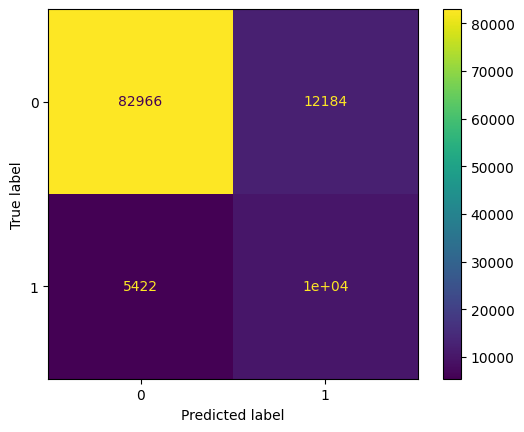

In [17]:
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, predictions_002)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=rfc_model_002.classes_
)
disp.plot()
plt.show()

In [18]:
from sklearn.metrics import f1_score

f1_002 = f1_score(y_test, predictions_002)

f1_002

0.5371227258386791

Next we'll train a model with a subset of the features based on domain knowledge.

In [19]:
custom_filtered_features_df = feature_importances_df.loc[
    feature_importances_df["importance"] > 0.01
].copy()

custom_filtered_features_df

,feature,importance
1505,Categorical Pipeline__augmentation_of_labor_1.0,0.069416
1504,Categorical Pipeline__induction_of_labor_1.0,0.051625
1516,Categorical Pipeline__attendant_at_birth_3.0,0.050293
1585,Numerical Pipeline__time_of_birth,0.047317
1588,Numerical Pipeline__prior_births_now_living,0.023729
1600,Numerical Pipeline__number_of_previous_cesarean,0.021690
1514,Categorical Pipeline__trial_of_labor_attempted...,0.018494
1598,Numerical Pipeline__BMI,0.018152
1602,Numerical Pipeline__birth_weight_in_grams,0.017497
1550,Categorical Pipeline__obstetric_estimate_recod...,0.015310


Some of these features are duplicates of each other, or otherwise highly correlated. First, we'll clean those up.

In [20]:
custom_filtered_features_df = custom_filtered_features_df.drop([1597, 1601])

Although paternal age plays a factor in fertility and pregnancy, we don't believe it to play a factor in VBAC. We'll rely on the mother's age instead of both ages.

In [21]:
custom_filtered_features_df = custom_filtered_features_df.drop([1587])

We can now train our model.

In [22]:
x_train_custom = x_train_unfiltered[
    :,
    custom_filtered_features_df.index.tolist(),
]
x_test_custom = x_test_unfiltered[
    :,
    custom_filtered_features_df.index.tolist(),
]

In [23]:
from sklearn.ensemble import RandomForestClassifier

rfc_model_custom = RandomForestClassifier(random_state=14, class_weight="balanced")

rfc_model_custom.fit(x_train_custom, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [24]:
predictions_custom = rfc_model_custom.predict(x_test_custom)

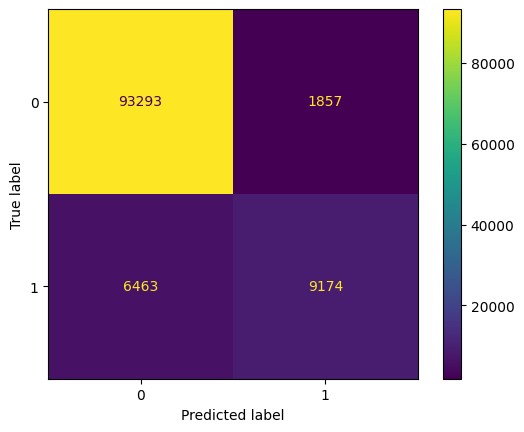

In [25]:
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, predictions_custom)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=rfc_model_custom.classes_
)
disp.plot()
plt.show()

In [26]:
from sklearn.metrics import f1_score

f1_custom = f1_score(y_test, predictions_custom)

f1_custom

0.688015599220039

### Findings

In [27]:
print("Importance 0.01 F1 score: ", f1_001)
print("Importance 0.015 F1 score: ", f1_0015)
print("Importance 0.02 F1 score: ", f1_002)
print("Custom filter F1 score: ", f1_custom)

Importance 0.01 F1 score:  0.6894244144516711
Importance 0.015 F1 score:  0.6763430587197766
Importance 0.02 F1 score:  0.5371227258386791
Custom filter F1 score:  0.688015599220039


The 0.01 and custom models performed at approximately the same level. We will move forward with the custom model, as its smaller feature set will be easier to implement in an interactive format.

In [28]:
best_model = rfc_model_custom

In [29]:
from pickle import dump

dump(best_model, open("../../../models/vbac/rfc_model.pkl", "wb"))

### Conclusion

Our RFC model is able to predict VBAC outcomes with moderate accuracy. A more complex model may have greater success at accurate predictions.